### Setup base model and data

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent)) 
  
from ablation_utils.uncertainty import (
    UncertaintyData, ProbabilityEnsemble,
    ConstantEU, EntropyEU, VarianceEU, KNNRadius, MMIUncertainty, conformal_pvalues_loo
)
from sklearn.linear_model import LogisticRegression

os.makedirs("plots", exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# Leave exactly one `data = ...` block uncommented

from ablation_utils.data import blobs, pendigits, fashion_mnist

data = pendigits(eu_classes=(5, 6, 7, 8, 9), eu_keep=0.25, seed=0)
dataname="PENDIGITS"
#data = blobs(eu_classes=(5, 6, 7, 8), eu_keep=0.1, seed=0)
#dataname="BLOBS"
#data = fashion_mnist(eu_keep=0.3, n_train=10000, n_calib=5000, n_test=20000,seed=0)
#dataname="FASHION_MNIST"


X_train, y_train = data.X_train, data.y_train
X_calib, y_calib = data.X_calib, data.y_calib
X_test,  y_test  = data.X_test,  data.y_test

num_classes = data.num_classes
n_calib     = data.n_calib
group_test   = data.group_test      

print(data.summary())

pendigits: K = 10, n_train = 3785, n_calib = 1000, n_test = 3000
  eu classes     [5, 6, 7, 8, 9]
  train / class  [612, 614, 635, 564, 622, 146, 143, 163, 144, 142]
  rest   train   3047   test   1572
  eu     train    738   test   1428


In [3]:
# model = RandomForestClassifier(n_estimators=100, max_iter=1000)
# model.fit(X_train, y_train)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# adjust max_depth to make model more or less capable
# 6 used for blobs and digits data
model = ProbabilityEnsemble(DecisionTreeClassifier(max_depth=6), k=25)
model.fit(X_train, y_train)

def scores_all(Xa):
    """(m, K) matrix of S(x, y) for every candidate label y."""
    return 1.0 - model.predict_proba(Xa)
    #P = np.clip(model.predict_proba(Xa), 1e-12, 1.0)
    #return -np.log(P)    

S_calib_all = scores_all(X_calib)                    # (n_calib, K)
S_calib = S_calib_all[np.arange(n_calib), y_calib]   # (n_calib,)
S_test_all = scores_all(X_test)
S_test  = S_test_all[np.arange(len(X_test)), y_test]
acc = model.score(X_train, y_train)

print("base model accuracy (calib):", (model.predict(X_calib) == y_calib).mean())

base model accuracy (calib): 0.887


### Training a model of coverage levels

In [4]:
# set up for ablation - determine uncertainty methods to use
uncertainty_methods = {
    "constant": ConstantEU(),
    "entropy":  EntropyEU(model),
    "variance": VarianceEU(model),
    "knn":      KNNRadius(n_neighbors=25, standardize=False),
    "mmi_pi":   MMIUncertainty(form="pi"),
}

In [5]:
# construct the loo data needed for all uncertainty methods

n_loo = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib                
E_loo = (n_loo + 1) * S_calib_all / (Sigma_loo[:, None] + S_calib_all)   
feats_loo = np.concatenate([Sigma_loo[:, None], np.sort(S_calib_all, axis=1)], axis=1)
P_loo     = conformal_pvalues_loo(S_calib, S_calib_all)


In [6]:
# bundle the calibration data
train_data = UncertaintyData(X=X_train)
calib_data = UncertaintyData(X=X_calib, E=E_loo, S=S_calib_all, P=P_loo)

for method in uncertainty_methods.values():
    method.fit(train_data).calibrate(calib_data)


c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

In [7]:
# setup for statistical tests
EU      = (data.group_test == "eu")          
METHODS = list(uncertainty_methods)
AWARE   = [m for m in METHODS if m != "constant"]
print(f"eu: {EU.sum()}   rest: {(~EU).sum()}   eu_classes: {data.eu_classes}")

eu: 1428   rest: 1572   eu_classes: (5, 6, 7, 8, 9)


In [ ]:
import ablation_utils.neural_net as anet

# ablation config
train_loaders = {
    name: anet.make_loader(
        Sigma = Sigma_loo,
        S     = S_calib_all,
        E     = E_loo,
        u     = method.transform_loo(calib_data),
        batch_size = 32,
    )
    for name, method in uncertainty_methods.items()
}
# optimal lam changes with dataset
num_runs, num_epochs, lr = 4, 200, 1e-3

In [9]:
print(f"highest recommended lambda: {(num_classes-1) * E_loo.max()}")
lam=int(((num_classes-1) * E_loo.max())//5)*5

highest recommended lambda: 45.466950787198016


In [10]:

# # Uncomment this cell to find a good value of lam for a new dataset. The value of lam is the regularization parameter for the alpha net. Lambdas too high will collapse to alpha=0. Lambdas too low will produce empty sets.
# # highest value here should be based on highest recommended lambda
# lambdas = [5, 10, 30, 60]

# lam_results = anet.multi_lambda_run_train_alpha_net(
#     train_loaders["constant"], lambdas,
#     num_epochs=100, lr=lr, num_runs=1, device=device, 
# )

# print(f"K = {num_classes}, n_calib = {n_calib}, alpha floor = {1/(n_calib+1):.4f}")
# for lam in lambdas:
#     a = lam_results[lam]["alphas"][:, -1]
#     s = lam_results[lam]["sizes"][:, -1]
#     print(f"  lambda {lam:>4}   alpha {a.mean():.3f} ± {a.std():.3f}"
#           f"   size {s.mean():.2f} ± {s.std():.2f}")


In [11]:

all_results = anet.run_uncertainty_ablation(
    train_loaders, lam=10, num_epochs=num_epochs,
    lr=lr, num_runs=num_runs, device=device, patience=20
)


[constant] run 1/4
  lam 10 | run 1 | epoch 0/200 | loss 4.2687 | size 1.2824 | alpha 0.2986
  lam 10 | run 1 | epoch 25/200 | loss 3.7531 | size 1.2517 | alpha 0.2501
  lam 10 | run 1 | epoch 50/200 | loss 3.7049 | size 1.1611 | alpha 0.2544
  lam 10 | run 1 | epoch 75/200 | loss 3.6984 | size 1.1208 | alpha 0.2578
  early stop at epoch 83

[constant] run 2/4
  lam 10 | run 2 | epoch 0/200 | loss 3.8713 | size 1.3541 | alpha 0.2517
  lam 10 | run 2 | epoch 25/200 | loss 3.7137 | size 1.1936 | alpha 0.2520
  lam 10 | run 2 | epoch 50/200 | loss 3.6903 | size 1.1179 | alpha 0.2572
  lam 10 | run 2 | epoch 75/200 | loss 3.6886 | size 1.1082 | alpha 0.2580
  early stop at epoch 89

[constant] run 3/4
  lam 10 | run 3 | epoch 0/200 | loss 4.1640 | size 1.3002 | alpha 0.2864
  lam 10 | run 3 | epoch 25/200 | loss 3.7506 | size 1.2597 | alpha 0.2491
  lam 10 | run 3 | epoch 50/200 | loss 3.6885 | size 1.1262 | alpha 0.2562
  early stop at epoch 70

[constant] run 4/4
  lam 10 | run 4 | epoc

c:\Users\User\Documents\learning-uncertainty-aware-policies\classification\neural_net.py:445: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


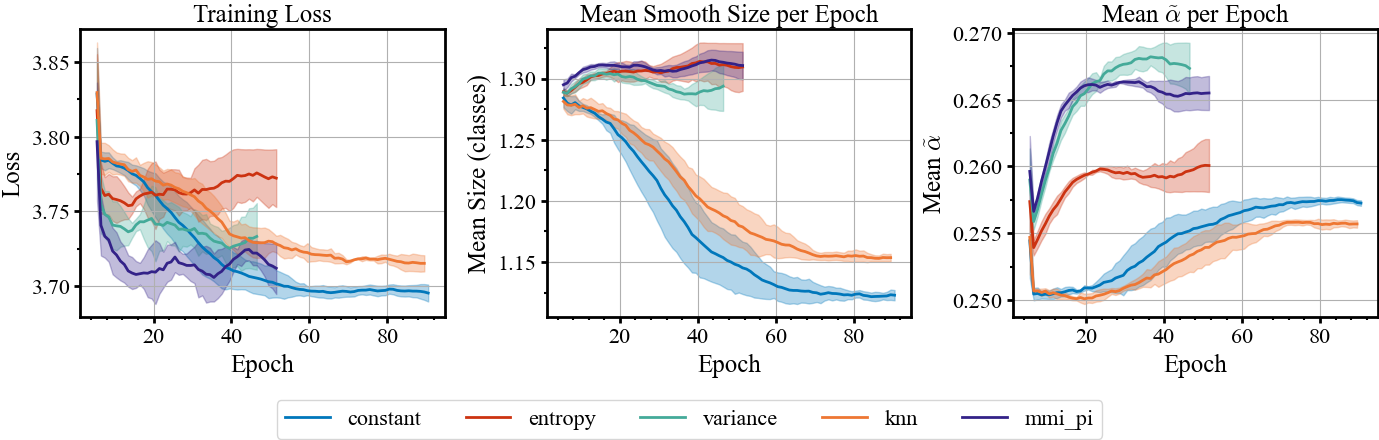

In [12]:
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import AutoMinorLocator
from tueplots import bundles

os.makedirs("plots", exist_ok=True)


anet.plot_performance(all_results, path=f"plots/alpha_net_results_uq_ablation_{dataname}_data.pdf")

In [13]:
print([f"{r}: {all_results[r]["losses"].mean()}" for r in all_results.keys()])

['constant: 3.727504143040431', 'entropy: 3.775550132417785', 'variance: 3.7505513646219875', 'knn: 3.746320924325351', 'mmi_pi: 3.7284142018096254']


### Learned coverage policy evaluation

In [14]:
import numpy as np, pandas as pd, torch
from sklearn.neighbors import NearestNeighbors
from ablation_utils.uncertainty import UncertaintyData, conformal_pvalues
import neural_net as anet

ALPHA_FIXED, Q_TAIL = 0.10, 0.10

Sigma_test = float(S_calib.sum())
E_test     = (n_calib + 1) * S_test_all / (Sigma_test + S_test_all)
test_data  = UncertaintyData(X=X_test, E=E_test, S=S_test_all,
                             P=conformal_pvalues(S_calib, S_test_all))

def set_metrics(coverages, sizes, alphas):
    cov     = float(np.mean(coverages))
    a_mean  = float(np.mean(alphas))
    nominal = 1.0 - a_mean
    metrics = {
        "mean alpha":    a_mean,
        "nominal cov":   nominal,
        "coverage":      cov,
        "gap":           cov - nominal,        # < 0 means the coverage guarantee is broken
        "mean size":     float(np.mean(sizes)),
        "% empty":       100.0 * np.mean(np.asarray(sizes) == 0),
    }
    return metrics

def aggregate(per_run):
    return {k: (np.mean([r[k] for r in per_run]), np.std([r[k] for r in per_run]))
            for k in per_run[0]}


rows, curves, sizes_for_hist = {}, {}, {}

# --- learned policies ---------------------------------------------------------
for name, method in uncertainty_methods.items():
    u_test  = method.transform_normalized(test_data)
    per_run = []
    for r, net in enumerate(all_results[name]["nets"]):
        cov, sz, a = anet.evaluate_adaptive(
            net, S_test_all, y_test, Sigma_test, u_test, n_calib,device=device)
        per_run.append(set_metrics(cov, sz, a))
        if r == 0:
            curves[name] = anet.reliability(cov, a)
            sizes_for_hist[name] = sz
    rows[name] = aggregate(per_run)
    
# --- table --------------------------------------------------------------------
metrics = list(next(iter(rows.values())))
df_num  = pd.DataFrame({m: {k: rows[k][m][0] for k in rows} for m in metrics})
df_std  = pd.DataFrame({m: {k: rows[k][m][1] for k in rows} for m in metrics})
df_fmt  = df_num.round(3).astype(str) + " ± " + df_std.round(3).astype(str)

print(f"Test split, n = {len(X_test)}, K = {num_classes}, "
      f"baselines at alpha = {ALPHA_FIXED}")
print("gap = empirical coverage - (1 - mean alpha); negative means over-promised\n")
print(df_fmt.to_string())
print("\n" + df_num.round(3).to_latex())

Test split, n = 3000, K = 10, baselines at alpha = 0.1
gap = empirical coverage - (1 - mean alpha); negative means over-promised

             mean alpha    nominal cov       coverage            gap      mean size        % empty
constant  0.257 ± 0.002  0.743 ± 0.002  0.905 ± 0.003  0.162 ± 0.002   1.04 ± 0.008  3.383 ± 0.329
entropy   0.258 ± 0.009  0.742 ± 0.009  0.953 ± 0.007  0.212 ± 0.003  1.238 ± 0.042      0.0 ± 0.0
variance  0.265 ± 0.001  0.735 ± 0.001  0.952 ± 0.001  0.216 ± 0.001  1.228 ± 0.008      0.0 ± 0.0
knn       0.253 ± 0.002  0.747 ± 0.002  0.922 ± 0.005  0.175 ± 0.003   1.091 ± 0.02  1.758 ± 0.487
mmi_pi     0.26 ± 0.005   0.74 ± 0.005  0.952 ± 0.002  0.212 ± 0.003   1.251 ± 0.02      0.0 ± 0.0

\begin{tabular}{lrrrrrr}
\toprule
 & mean alpha & nominal cov & coverage & gap & mean size & % empty \\
\midrule
constant & 0.257000 & 0.743000 & 0.905000 & 0.162000 & 1.040000 & 3.383000 \\
entropy & 0.258000 & 0.742000 & 0.953000 & 0.212000 & 1.238000 & 0.000000 \\
varianc

In [15]:
A, SZ, MISS = {}, {}, {}
for name, method in uncertainty_methods.items():
    u_test = method.transform_normalized(test_data)
    runs = [anet.evaluate_adaptive(net, S_test_all, data.y_test, Sigma_test,
                                   u_test, data.n_calib, device=device)
            for net in all_results[name]["nets"]]
    A[name]    = np.mean([np.asarray(a, float) for _, _, a in runs], axis=0)
    SZ[name]   = np.mean([np.asarray(s, float) for _, s, _ in runs], axis=0)
    MISS[name] = np.mean([1.0 - np.asarray(c, float) for c, _, _ in runs], axis=0)

OUTCOMES = {"alpha": A, "size": SZ, "miscoverage": MISS}

In [16]:
import numpy as np
import pandas as pd
import pingouin as pg
from scipy import stats
from statsmodels.stats.multitest import multipletests

CONTROL = "constant"

DATA = {}

for metric, V in OUTCOMES.items():
    rows = []

    for i in range(len(EU)):
        region = "High EU" if EU[i] else "Low EU"

        for method in METHODS:
            rows.append({
                "id": i,
                "Method": method,
                "Region": region,
                "value": float(V[method][i])
            })

    DATA[metric] = pd.DataFrame(rows)

# Inspect one metric
DATA["alpha"].head()

,id,Method,Region,value
0,0,constant,High EU,0.252831
1,0,entropy,High EU,0.255611
2,0,variance,High EU,0.260950
3,0,knn,High EU,0.248618
4,0,mmi_pi,High EU,0.263442


In [17]:
# Mixed ANOVA: Model × Region interaction

ANOVA_RESULTS = {}

for metric, df in DATA.items():

    aov = pg.mixed_anova(
        data=df,
        dv="value",
        within="Method",      # Model is repeated within test point
        between="Region",     # Region differs between test points
        subject="id"          # test point / observation
    )

    ANOVA_RESULTS[metric] = aov

    print(f"\n{'='*70}")
    print(f"{metric.upper()} — MIXED ANOVA")
    print("=" * 70)
    print(aov.round(4).to_string(index=False))


ALPHA — MIXED ANOVA
     Source     SS  DF1   DF2     MS        F  p_unc  p_GG_corr    np2    eps sphericity  W_spher  p_spher
     Region 0.0178    1  2998 0.0178 193.9347    0.0        NaN 0.0608    NaN        NaN      NaN      NaN
     Method 0.2098    4 11992 0.0525 168.3992    0.0        0.0 0.0532 0.2894      False   0.0004      0.0
Interaction 0.3023    4 11992 0.0756 242.5884    0.0        NaN 0.0749    NaN        NaN      NaN      NaN

SIZE — MIXED ANOVA
     Source       SS  DF1   DF2      MS        F  p_unc  p_GG_corr    np2    eps sphericity  W_spher  p_spher
     Region  47.9907    1  2998 47.9907  82.1052    0.0        NaN 0.0267    NaN        NaN      NaN      NaN
     Method 112.5578    4 11992 28.1395 321.6553    0.0        0.0 0.0969 0.3586      False   0.0244      0.0
Interaction  49.4430    4 11992 12.3607 141.2927    0.0        NaN 0.0450    NaN        NaN      NaN      NaN

MISCOVERAGE — MIXED ANOVA
     Source      SS  DF1   DF2      MS        F  p_unc  p_GG_cor

In [18]:
DID_RESULTS = {}

for metric, V in OUTCOMES.items():

    results = []

    for m in AWARE:

        # Alternative - control for every test point
        gap = V[m] - V[CONTROL]

        high = gap[EU]
        low = gap[~EU]

        # Welch independent-samples t-test
        test = pg.ttest(
            high,
            low,
            paired=False,
            correction=True
        )

        r = test.iloc[0]

        results.append({
            "Method": m,
            "Delta_High": high.mean(),
            "Delta_Low": low.mean(),
            "DiD": high.mean() - low.mean(),
            "CI95_low": r["CI95"][0],
            "CI95_high": r["CI95"][1],
            "Cohen_d": r["cohen_d"],
            "T": r["T"],
            "dof": r["dof"],
            "p": r["p_val"]
        })

    result = pd.DataFrame(results)

    # Correct the four alternative-vs-control interaction tests
    result["p_holm"] = multipletests(
        result["p"],
        method="holm"
    )[1]

    DID_RESULTS[metric] = result

    print(f"\n{'='*80}")
    print(f"{metric.upper()} — DIFFERENCE-IN-DIFFERENCES")
    print("=" * 80)
    print(result.round(4).to_string(index=False))


ALPHA — DIFFERENCE-IN-DIFFERENCES
  Method  Delta_High  Delta_Low     DiD  CI95_low  CI95_high  Cohen_d        T       dof   p  p_holm
 entropy     -0.0099     0.0117 -0.0216     -0.02      -0.02   0.6948 -18.6033 2333.7868 0.0     0.0
variance     -0.0053     0.0197 -0.0251     -0.03      -0.02   0.7315 -19.5695 2302.3899 0.0     0.0
     knn     -0.0095     0.0017 -0.0112     -0.01      -0.01   1.2499 -33.2358 2071.8700 0.0     0.0
  mmi_pi     -0.0073     0.0122 -0.0196     -0.02      -0.02   0.5168 -13.9227 2565.2330 0.0     0.0

SIZE — DIFFERENCE-IN-DIFFERENCES
  Method  Delta_High  Delta_Low    DiD  CI95_low  CI95_high  Cohen_d       T       dof   p  p_holm
 entropy      0.3412     0.0671 0.2741      0.23       0.31   0.5125 13.5926 1973.6612 0.0     0.0
variance      0.3204     0.0668 0.2536      0.21       0.29   0.4819 12.7825 1982.3361 0.0     0.0
     knn      0.0989     0.0073 0.0916      0.08       0.11   0.4299 11.3550 1831.6357 0.0     0.0
  mmi_pi      0.3613     0.073

In [19]:
posthoc=pg.pairwise_tests(dv='value', within='Method', between='Region',
                  subject='id', data=df, padjust='holm', correction=True)
print(posthoc.round(4).to_string(index=False))

       Contrast   Method        A        B Paired Parametric        T       dof alternative  p_unc  p_corr p_adjust      BF10  hedges
         Method        - constant  entropy   True       True  13.0705 2999.0000   two-sided 0.0000  0.0000     holm 2.279e+34  0.1920
         Method        - constant      knn   True       True   8.2352 2999.0000   two-sided 0.0000  0.0000     holm 7.274e+12  0.0593
         Method        - constant   mmi_pi   True       True  12.6046 2999.0000   two-sided 0.0000  0.0000     holm 7.909e+31  0.1861
         Method        - constant variance   True       True  12.4258 2999.0000   two-sided 0.0000  0.0000     holm  9.44e+30  0.1819
         Method        -  entropy      knn   True       True -10.9248 2999.0000   two-sided 0.0000  0.0000     holm 5.049e+23 -0.1342
         Method        -  entropy   mmi_pi   True       True  -0.7237 2999.0000   two-sided 0.4693  0.9386     holm     0.027 -0.0044
         Method        -  entropy variance   True       True  

In [20]:
import pandas as pd
from scipy import stats

def welch(x, y):
    """Two independent groups (eu vs rest)."""
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    diff   = x.mean() - y.mean()
    se     = np.sqrt(vx/nx + vy/ny)
    df     = se**4 / (vx**2/(nx**2*(nx-1)) + vy**2/(ny**2*(ny-1)))
    crit   = stats.t.ppf(0.975, df)
    sp     = np.sqrt(((nx-1)*vx + (ny-1)*vy) / (nx+ny-2))
    return dict(mean_eu=x.mean(), sd_eu=np.sqrt(vx),
                mean_rest=y.mean(), sd_rest=np.sqrt(vy),
                diff=diff, ci_lo=diff-crit*se, ci_hi=diff+crit*se,
                d=(diff/sp if sp > 0 else np.nan),
                p=stats.ttest_ind(x, y, equal_var=False).pvalue)

def paired(d):
    """Same test points under two methods."""
    n, m, sd = len(d), d.mean(), d.std(ddof=1)
    se, crit = sd/np.sqrt(n), stats.t.ppf(0.975, n-1)
    return dict(mean_diff=m, sd_diff=sd,
                ci_lo=m-crit*se, ci_hi=m+crit*se,
                d_z=(m/sd if sd > 0 else np.nan),
                p=stats.ttest_1samp(d, 0).pvalue)

for label, V in OUTCOMES.items():
    # Q1 + Q2 : eu vs rest, one method at a time
    q12 = pd.DataFrame([{"method": m, **welch(V[m][EU], V[m][~EU])}
                        for m in METHODS]).set_index("method")

    # Q3 : each aware method vs constant, paired, within each stratum
    q3 = pd.DataFrame([{"method": m, "stratum": g,
                        **paired((V[m] - V["constant"])[msk])}
                       for m in AWARE
                       for g, msk in [("eu", EU), ("rest", ~EU),
                                      ("all", np.ones(len(EU), bool))]]
                      ).set_index(["method", "stratum"])

    # Q4 : rank the aware methods by the Q1 effect size
    q4 = q12.loc[AWARE, ["diff", "ci_lo", "ci_hi", "d"]]
    q4 = q4.reindex(q4["d"].abs().sort_values(ascending=False).index)

    print(f"\n{'='*70}\n{label.upper()}\n{'='*70}")
    print("\n-- eu vs rest, per method (Welch) --")
    print(q12.round(4).to_string())
    print("\n-- aware vs constant, paired --")
    print(q3.round(4).to_string())
    print("\n-- aware methods ranked by |d| --")
    print(q4.round(4).to_string())


ALPHA

-- eu vs rest, per method (Welch) --
          mean_eu   sd_eu  mean_rest  sd_rest    diff   ci_lo   ci_hi       d       p
method                                                                               
constant   0.2640  0.0289     0.2507   0.0194  0.0133  0.0115  0.0151  0.5456  0.0000
entropy    0.2541  0.0106     0.2624   0.0060 -0.0083 -0.0089 -0.0077 -0.9811  0.0000
variance   0.2587  0.0154     0.2704   0.0086 -0.0117 -0.0127 -0.0108 -0.9544  0.0000
knn        0.2545  0.0203     0.2524   0.0156  0.0021  0.0008  0.0034  0.1170  0.0016
mmi_pi     0.2567  0.0156     0.2629   0.0124 -0.0062 -0.0073 -0.0052 -0.4465  0.0000

-- aware vs constant, paired --
                  mean_diff  sd_diff   ci_lo   ci_hi     d_z       p
method   stratum                                                    
entropy  eu         -0.0099   0.0378 -0.0119 -0.0079 -0.2614  0.0000
         rest        0.0117   0.0234  0.0106  0.0129  0.5015  0.0000
         all         0.0014   0.0329  0.0003

In [21]:
rows, curves, sizes_for_hist = {}, {}, {}
raw = {}                                              

for name, method in uncertainty_methods.items():
    u_test  = method.transform_normalized(test_data)
    per_run, per_run_raw = [], []                     
    for r, net in enumerate(all_results[name]["nets"]):
        cov, sz, a = anet.evaluate_adaptive(
            net, S_test_all, y_test, Sigma_test, u_test, n_calib, device=device)
        per_run.append(set_metrics(cov, sz, a))
        per_run_raw.append((cov, sz, a))               
        if r == 0:
            curves[name] = anet.reliability(cov, a)
            sizes_for_hist[name] = sz
    rows[name] = aggregate(per_run)
    raw[name] = per_run_raw                                 



C:\Users\User\AppData\Local\Temp\ipykernel_28616\3277597033.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


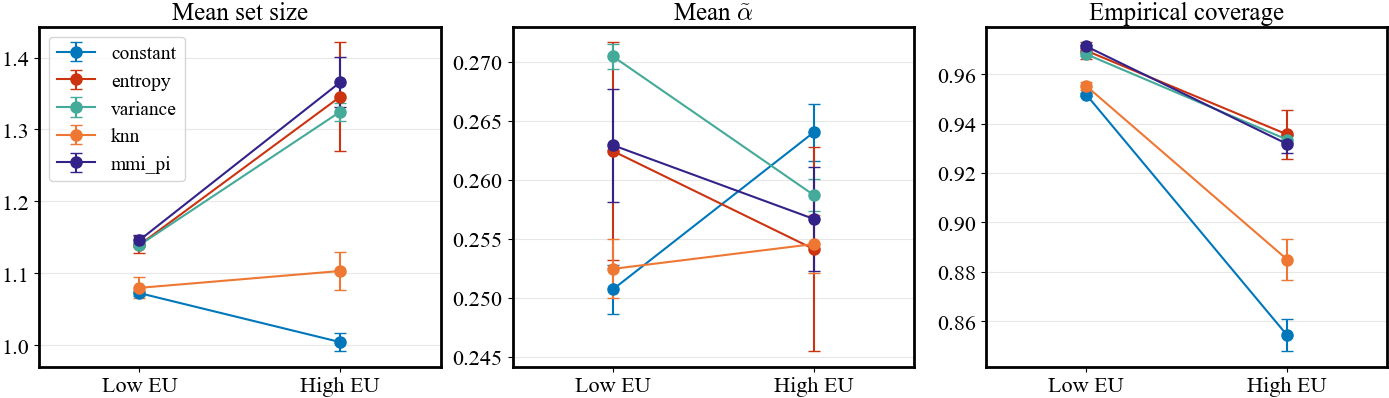

In [22]:
def to_np(v):
    return v.detach().cpu().numpy() if hasattr(v, "detach") else np.asarray(v)

GROUPS  = ["rest", "eu"]
LABEL   = {"rest": "Low EU", "eu": "High EU"}
METRICS = [("size",     "Mean set size"),
           ("alpha",    r"Mean $\tilde\alpha$"),
           ("coverage", "Empirical coverage")]

S_np   = to_np(S_test_all)
y_np   = to_np(y_test).astype(int)
g_np   = np.asarray(group_test)
groups = [g for g in GROUPS if (g_np == g).any()]
names  = list(raw)
colors = dict(zip(names, anet._PALETTE))

plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 18, "axes.titlesize": 18,
    "xtick.labelsize": 16, "ytick.labelsize": 16,
    "legend.fontsize": 14, "lines.linewidth": 2, "axes.linewidth": 2,
})


def draw(ax, v, x, color, label):
    ax.errorbar(x, v.mean(axis=0), yerr=v.std(axis=0), color=color, label=label,
                marker="o", markersize=8, linewidth=1.5, capsize=4, elinewidth=1.5)


def style(ax, labels, title):
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)

def group_stats(cov, sz, a, m):
    cov, sz, a = (to_np(v).astype(float) for v in (cov, sz, a))
    return {"size": sz[m].mean(), "alpha": a[m].mean(), "coverage": cov[m].mean()}

stat = {n: {k: np.array([[group_stats(*run, g_np == g)[k] for g in groups] for run in raw[n]])
            for k, _ in METRICS}
        for n in names}

fig, axs = plt.subplots(1, len(METRICS), figsize=(4.7 * len(METRICS), 4.2))
for ax, (key, title) in zip(axs, METRICS):
    for n in names:
        draw(ax, stat[n][key], np.arange(len(groups)), colors[n], n)
    style(ax, [LABEL[g] for g in groups], title)
axs[0].legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(f"plots/groups_by_method_{dataname}_data.pdf", bbox_inches="tight")
plt.show()

In [23]:
# Class-wise MISCOVERAGE (1 - coverage)
# difficulty heuristic: mean true-class score on each class's test points
HIGHER_IS_HARDER = True          # True if S_np is a nonconformity score, False if it's a softmax prob

true_score = S_np[np.arange(len(y_np)), y_np]
classes    = np.unique(y_np)
order      = np.argsort([true_score[y_np == c].mean() for c in classes])
classes    = classes[order if HIGHER_IS_HARDER else order[::-1]]   # easy -> hard
k          = max(1, len(classes) // 3)
easy, hard = slice(0, k), slice(len(classes) - k, None)

cmis, marg = {}, {}
for n in names:
    covs    = [to_np(cov).astype(float) for cov, _, _ in raw[n]]
    cmis[n] = np.array([[1.0 - c[y_np == cl].mean() for cl in classes] for c in covs])
    marg[n] = np.array([1.0 - c.mean() for c in covs])

metrics = {n: {
    r"marginal miscov":  marg[n],
    r"max - min":        cmis[n].max(1) - cmis[n].min(1),
    r"max class miscov": cmis[n].max(1),
} for n in names}

def fmt(v, tex=False):
    return f"{v.mean():.3f} {'$\\pm$' if tex else '±'} {v.std():.3f}"

summary   = pd.DataFrame({n: {m: fmt(v)       for m, v in d.items()} for n, d in metrics.items()}).T
summary_x = pd.DataFrame({n: {m: fmt(v, True) for m, v in d.items()} for n, d in metrics.items()}).T
per_class = pd.DataFrame({n: cmis[n].mean(0) for n in names}, index=classes).T.round(3)
per_class.columns.name = "class (easy -> hard)"

print("Smaller max-min = miscoverage more uniform across classes\n")
print(summary.to_string(), "\n")
print("Class miscoverage, mean over runs")
print(per_class.to_string(), "\n")

latex = summary_x.to_latex(
    escape=False, column_format="l" + "r" * summary_x.shape[1],
    caption=r"Class-conditional miscoverage. Mean $\pm$ sd over runs; "
            r"easy/hard are the first and last thirds of classes ranked by "
            r"mean true-class score.",
    label="tab:class-miscoverage",
)
print(latex)

Smaller max-min = miscoverage more uniform across classes

         marginal miscov      max - min max class miscov
constant   0.095 ± 0.003  0.187 ± 0.010    0.197 ± 0.010
entropy    0.047 ± 0.007  0.101 ± 0.009    0.106 ± 0.010
variance   0.048 ± 0.001  0.096 ± 0.003    0.102 ± 0.003
knn        0.078 ± 0.005  0.164 ± 0.012    0.170 ± 0.012
mmi_pi     0.048 ± 0.002  0.099 ± 0.002    0.106 ± 0.002 

Class miscoverage, mean over runs
class (easy -> hard)      0      4      6      3      2      1      8      7      5      9
constant              0.009  0.028  0.045  0.078  0.019  0.107  0.161  0.185  0.196  0.152
entropy               0.006  0.006  0.023  0.033  0.016  0.088  0.079  0.101  0.102  0.022
variance              0.006  0.008  0.031  0.039  0.016  0.088  0.079  0.102  0.099  0.027
knn                   0.006  0.023  0.044  0.077  0.019  0.099  0.140  0.146  0.170  0.083
mmi_pi                0.006  0.010  0.026  0.019  0.016  0.090  0.097  0.105  0.092  0.027 

\begin{table}
\